In [3]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from scipy.signal import welch

In [4]:
no_aces ="C:\\Users\\emros\\OneDrive\\Desktop\\EO_No_ACES_ processed"
print(os.path.exists(no_aces))

True


In [5]:
files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))

fs = 500  

In [6]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 48


In [7]:
print(signals)

[[-7.52375890e-01  6.07685900e-02 -2.48395270e-01 ...  7.21766210e-01
   6.82928320e-01  3.14127060e-01]
 [-4.29292950e-01 -3.99103800e-02  5.16569500e-02 ...  9.36677990e-01
   6.72296560e-01  2.07954160e-01]
 [-2.10605000e-03 -4.09869000e-03  2.99578990e-01 ...  1.00526526e+00
   5.56222700e-01  4.38135300e-02]
 ...
 [-7.40993780e-01 -3.62292670e-01 -2.08356460e-01 ...  5.59733680e-01
   3.79831480e-01  1.20066000e-03]
 [-9.80908990e-01 -3.26546240e-01 -4.25367070e-01 ...  2.08619580e-01
   2.52941910e-01  4.43310000e-04]
 [-1.13697462e+00 -3.20811260e-01 -4.60332740e-01 ...  1.22268040e-01
   4.53414830e-01  2.01236410e-01]]


In [8]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd = np.mean(all_subject_psd, axis=0)

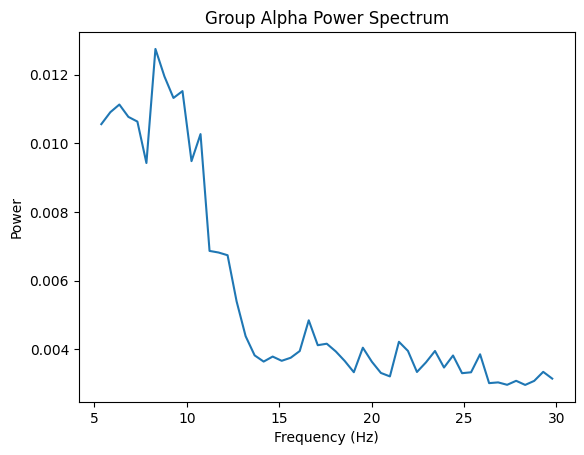

In [9]:
import matplotlib.pyplot as plt

alpha_mask = (freqs >= 5) & (freqs <= 30)

plt.plot(freqs[alpha_mask], group_psd[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

# Another version

In [10]:
eps = 1e-12
log_psd = np.log10(group_psd + eps)

In [11]:

# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

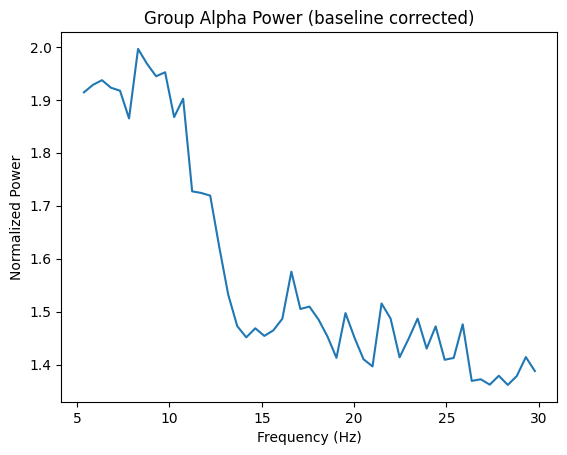

In [12]:
plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

### Z-score

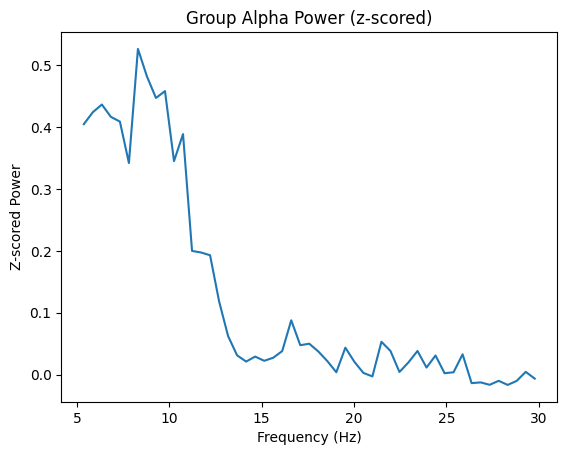

In [13]:
psd_mean = np.mean(group_psd)
psd_std = np.std(group_psd)
psd_z = (group_psd - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# 2nd version

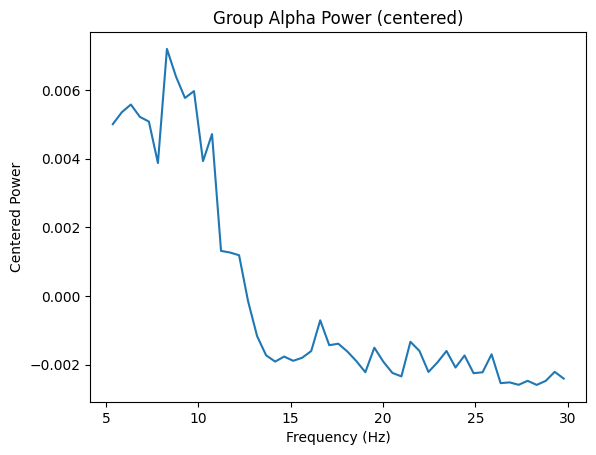

In [14]:
alpha_power = group_psd[alpha_mask]
alpha_power_centered = alpha_power - np.mean(alpha_power)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

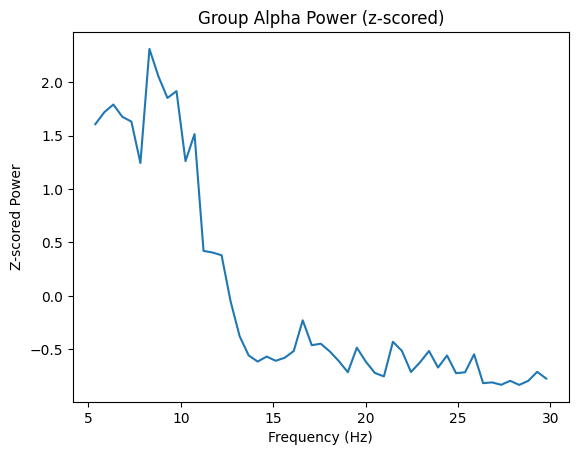

In [15]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

plt.plot(freqs[alpha_mask], alpha_power_z)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# ACEs Eyes Open

In [16]:
ACEs = "C:\\Users\\emros\\OneDrive\\Desktop\\EO_ACES_Processed"

In [17]:
files = glob.glob(os.path.join(ACEs, "*AveOverTrials.txt"))

fs = 500

In [18]:
all_subject_psd_aces = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_aces.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_aces))

Subjects: 88


In [19]:
all_subject_psd_ACE = np.vstack(all_subject_psd_aces)

group_psd_ACE = np.mean(all_subject_psd_ACE, axis=0)

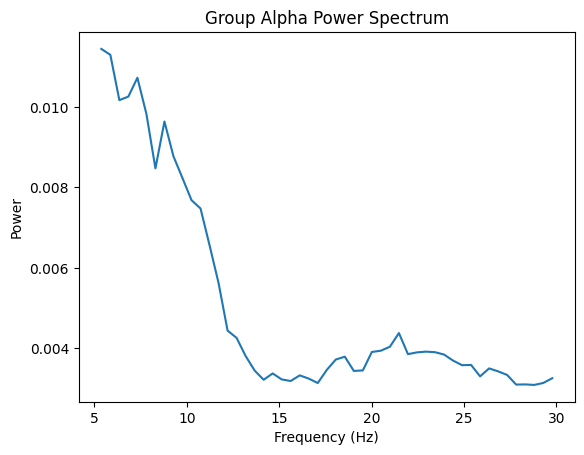

In [20]:
plt.plot(freqs[alpha_mask], group_psd_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

## Anotha one

In [21]:
eps = 1e-12
log_psd_ace = np.log10(group_psd_ACE + eps)

In [22]:
# baseline = mean across all frequencies
baseline_ace = np.mean(log_psd_ace)
log_psd_norm_ACE = log_psd_ace - baseline_ace

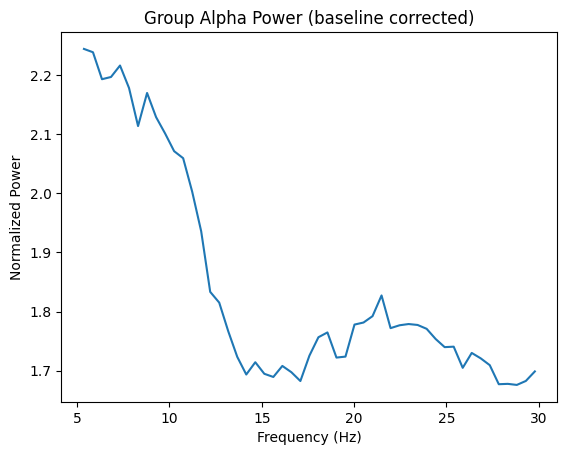

In [23]:
plt.plot(freqs[alpha_mask], log_psd_norm_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

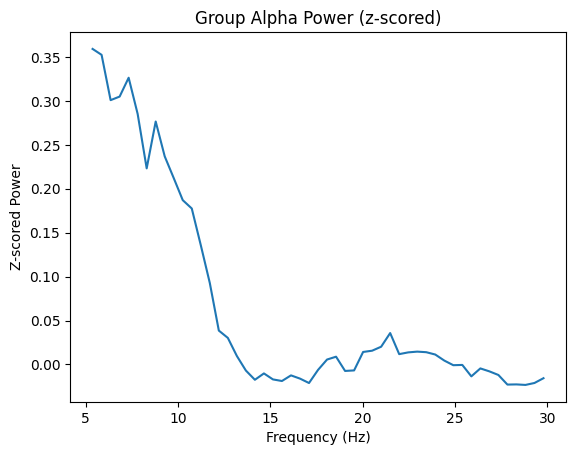

In [24]:
psd_mean_ace = np.mean(group_psd_ACE)
psd_std_ace = np.std(group_psd_ACE)
psd_z_ace = (group_psd_ACE - psd_mean_ace) / psd_std_ace

plt.plot(freqs[alpha_mask], psd_z_ace[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

## 2nd version

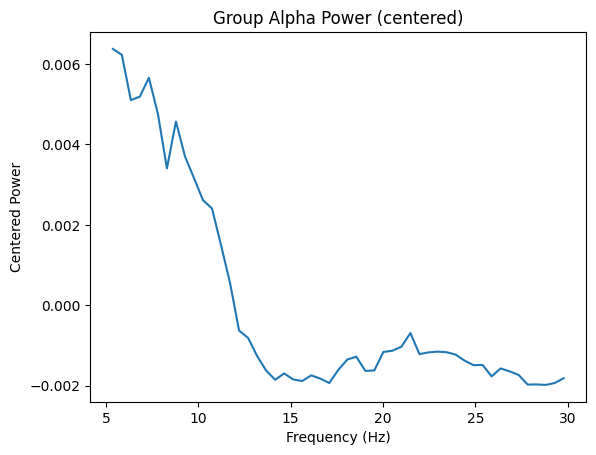

In [25]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_centered_ace = alpha_power_ace - np.mean(alpha_power_ace)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

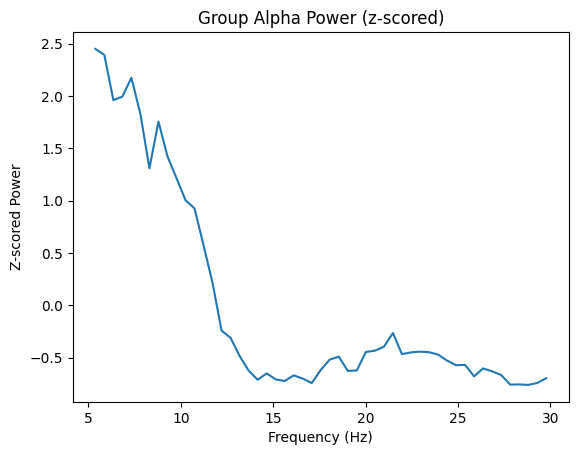

In [26]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

plt.plot(freqs[alpha_mask], alpha_power_z_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Togwether

In [44]:
alpha_mask = (freqs >= 8) & (freqs <= 12)

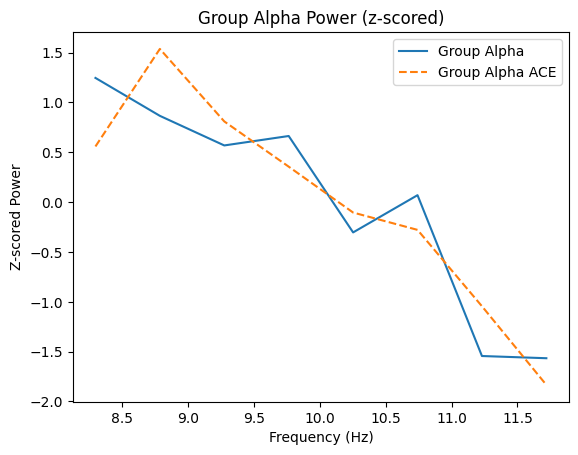

In [45]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_ACE[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

In [46]:
peak_freq_none = freqs[alpha_mask][np.argmax(alpha_power_z)]

In [47]:
print(peak_freq_none)

8.30078125


In [48]:
peak_freq = freqs[alpha_mask][np.argmax(alpha_power_z_ace)]

In [49]:
print(peak_freq)

8.7890625
